In [ ]:
import requests
import pandas as pd
import numpy as np
import re
import time
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

print("Libraries imported and NLTK data downloaded successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Libraries imported and NLTK data downloaded successfully!


In [ ]:
import requests
import pandas as pd
import time


GITHUB_TOKEN = "####################"
HEADERS = {"Authorization": f"token {GITHUB_TOKEN}"} if GITHUB_TOKEN else {}

def fetch_issues_from_multiple_repos(repo_list: list, issues_per_repo: int = 1000) -> pd.DataFrame:
    """
    Mines closed issues from a list of GitHub repositories and combines them.

    Args:
        repo_list (list): List of tuples containing (owner, repo_name).
        issues_per_repo (int): Target number of issues to extract per repository.

    Returns:
        pd.DataFrame: A master dataframe containing issues from all repositories.
    """
    all_issues_data = []

    for owner, repo in repo_list:
        print(f"\n--- Starting extraction for: {owner}/{repo} ---")
        page = 1
        repo_issue_count = 0

        while repo_issue_count < issues_per_repo:
            url = f"https://api.github.com/repos/{owner}/{repo}/issues"
            params = {
                "state": "closed",
                "per_page": 100, # Max allowed by GitHub API per page
                "page": page
            }

            response = requests.get(url, headers=HEADERS, params=params)

            # Error handling for rate limits
            if response.status_code != 200:
                print(f"API Error {response.status_code} on {owner}/{repo}. Check rate limits.")
                print("Moving to the next repository (if any)...")
                break

            issues = response.json()
            if not issues:
                print(f"No more issues found for {owner}/{repo}.")
                break

            for issue in issues:
                # keep actual issues, NOT pull requests
                if "pull_request" not in issue:
                    labels = [label['name'] for label in issue['labels']]

                    # Only keep issues that have at least one label
                    if labels:
                        all_issues_data.append({
                            "repository": f"{owner}/{repo}",
                            "issue_id": issue['number'],
                            "title": issue['title'],
                            "body": issue['body'] if issue['body'] else "",
                            "labels": labels
                        })
                        repo_issue_count += 1

                        if repo_issue_count >= issues_per_repo:
                            break # Stop if we reached the target for this repo

            print(f"Mined {repo_issue_count}/{issues_per_repo} issues for {repo}...")
            page += 1
            time.sleep(1.5)

    # Combine everything into a pandas DataFrame
    df_master = pd.DataFrame(all_issues_data)
    print(f"\n=== EXTRACTION COMPLETE! Total issues mined: {len(df_master)} ===")
    return df_master


# 10 Major Machine Learning and Data Science Repositories
target_repositories = [
    ("scikit-learn", "scikit-learn"), # Machine Learning
    ("pandas-dev", "pandas"),         # Data Analysis
    ("keras-team", "keras"),          # Deep Learning
    ("mlflow", "mlflow"),             # Machine Learning Lifecycle / MLOps
    ("pytorch", "pytorch"),           # Deep Learning Framework
    ("huggingface", "transformers"),  # Natural Language Processing
    ("numpy", "numpy"),               # Scientific Computing
    ("scipy", "scipy"),               # Scientific Computing
    ("matplotlib", "matplotlib"),     # Data Visualization
    ("ray-project", "ray")            # Distributed AI
]


df_issues = fetch_issues_from_multiple_repos(repo_list=target_repositories, issues_per_repo=1000)

# Display the distribution of issues collected per repository
print("\nDataset distribution:")
print(df_issues['repository'].value_counts())

# Show the first few rows
df_issues.head()


--- Starting extraction for: scikit-learn/scikit-learn ---
Mined 18/1000 issues for scikit-learn...
Mined 36/1000 issues for scikit-learn...
Mined 51/1000 issues for scikit-learn...
Mined 57/1000 issues for scikit-learn...
Mined 74/1000 issues for scikit-learn...
Mined 93/1000 issues for scikit-learn...
Mined 104/1000 issues for scikit-learn...
Mined 121/1000 issues for scikit-learn...
Mined 142/1000 issues for scikit-learn...
Mined 155/1000 issues for scikit-learn...
Mined 177/1000 issues for scikit-learn...
Mined 193/1000 issues for scikit-learn...
Mined 208/1000 issues for scikit-learn...
Mined 220/1000 issues for scikit-learn...
Mined 240/1000 issues for scikit-learn...
Mined 263/1000 issues for scikit-learn...
Mined 280/1000 issues for scikit-learn...
Mined 299/1000 issues for scikit-learn...
Mined 318/1000 issues for scikit-learn...
Mined 333/1000 issues for scikit-learn...
Mined 353/1000 issues for scikit-learn...
Mined 368/1000 issues for scikit-learn...
Mined 390/1000 issues 

,repository,issue_id,title,body,labels
0,scikit-learn/scikit-learn,33970,DataForge: Financial dataset + custom scraping...,> [!WARNING]\n> This issue is not yet ready fo...,"[spam, Needs Triage]"
1,scikit-learn/scikit-learn,33969,DataForge: Financial dataset + custom scraping...,> [!WARNING]\n> This issue is not yet ready fo...,"[spam, Needs Triage]"
2,scikit-learn/scikit-learn,33968,Feature: Add DataForge financial dataset example,> [!WARNING]\n> This issue is not yet ready fo...,"[spam, Needs Triage]"
3,scikit-learn/scikit-learn,33967,Feature: Add DataForge financial dataset example,> [!WARNING]\n> This issue is not yet ready fo...,"[spam, Needs Triage]"
4,scikit-learn/scikit-learn,33966,"Dataset sharing: Financial Data Bundle (3,518 ...",> [!WARNING]\n> This issue is not yet ready fo...,[Needs Triage]


In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_issue_text(text: str) -> str:
    """
    Cleans raw GitHub issue text by removing code snippets, URLs, and noise.

    Args:
        text (str): The raw text of the issue.

    Returns:
        str: Cleaned and lemmatized text ready for machine learning.
    """
    if not isinstance(text, str):
        return ""

    # 1. Remove code blocks (everything inside ``` ... ```)
    text = re.sub(r'```.*?```', ' ', text, flags=re.DOTALL)

    # 2. Remove inline code (everything inside ` ... `)
    text = re.sub(r'`.*?`', ' ', text)

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 4. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # 5. Keep only alphabetic characters (remove punctuation and numbers)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # 6. Convert to lowercase
    text = text.lower()

    # 7. Tokenization, Stop-word removal, and Lemmatization
    tokens = text.split()
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]

    return ' '.join(cleaned_tokens)

# Combine Title and Body, then clean it
print("Cleaning text data.")
df_issues['combined_text'] = df_issues['title'] + " " + df_issues['body']
df_issues['clean_text'] = df_issues['combined_text'].apply(clean_issue_text)

# Drop rows where cleaning resulted in empty text
df_issues = df_issues[df_issues['clean_text'].str.strip() != '']

print("Data cleaning complete! Here is a sample of the cleaned text:")
df_issues[['combined_text', 'clean_text']].head()

Cleaning text data. This might take a moment...
Data cleaning complete! Here is a sample of the cleaned text:


,combined_text,clean_text
0,DataForge: Financial dataset + custom scraping...,dataforge financial dataset custom scraping se...
1,DataForge: Financial dataset + custom scraping...,dataforge financial dataset custom scraping se...
2,Feature: Add DataForge financial dataset examp...,feature add dataforge financial dataset exampl...
3,Feature: Add DataForge financial dataset examp...,feature add dataforge financial dataset exampl...
4,"Dataset sharing: Financial Data Bundle (3,518 ...",dataset sharing financial data bundle real rec...


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Simplify and filter the labels
def get_primary_label(label_list):
    """Categorizes random GitHub labels into 3 main classes."""
    for label in label_list:
        label_lower = label.lower()
        if 'bug' in label_lower or 'defect' in label_lower:
            return 'bug'
        if 'enhancement' in label_lower or 'feature' in label_lower:
            return 'enhancement'
        if 'question' in label_lower or 'help' in label_lower or 'support' in label_lower:
            return 'question'
    return None # Ignore issues that don't fit these 3 categories

print("Filtering and grouping labels...")
df_issues['primary_label'] = df_issues['labels'].apply(get_primary_label)

# Drop rows that didn't match our 3 main categories
df_filtered = df_issues.dropna(subset=['primary_label']).copy()

print(f"Total issues remaining after filtering: {len(df_filtered)}")
print("\nClass Distribution:")
print(df_filtered['primary_label'].value_counts())

# 2. Train-Test Split (80% for training, 20% for testing)
X = df_filtered['clean_text']
y = df_filtered['primary_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Apply TF-IDF (Keeping the top 5000 most important words)
print("\nApplying TF-IDF Feature Extraction...")
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF extraction complete! Ready for model training.")

Filtering and grouping labels...
Total issues remaining after filtering: 6311

Class Distribution:
primary_label
bug            4692
enhancement    1122
question        497
Name: count, dtype: int64

Applying TF-IDF Feature Extraction...
TF-IDF extraction complete! Ready for model training.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore') # Hides annoying warnings

# --- 1. Random Forest ---
print("--- Training Random Forest Classifier ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

rf_predictions = rf_model.predict(X_test_tfidf)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_predictions) * 100:.2f}%\n")
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_predictions))

# --- 2. Support Vector Machine (SVM) ---
print("\n" + "="*50 + "\n")
print("--- Training Support Vector Machine (LinearSVC) ---")
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_tfidf, y_train)

svm_predictions = svm_model.predict(X_test_tfidf)
print(f"SVM Accuracy: {accuracy_score(y_test, svm_predictions) * 100:.2f}%\n")
print("SVM Classification Report:")
print(classification_report(y_test, svm_predictions))

--- Training Random Forest Classifier ---
Random Forest Accuracy: 90.66%

Random Forest Classification Report:
              precision    recall  f1-score   support

         bug       0.91      0.98      0.94       944
 enhancement       0.94      0.85      0.89       231
    question       0.67      0.25      0.36        88

    accuracy                           0.91      1263
   macro avg       0.84      0.69      0.73      1263
weighted avg       0.90      0.91      0.89      1263



--- Training Support Vector Machine (LinearSVC) ---
SVM Accuracy: 90.42%

SVM Classification Report:
              precision    recall  f1-score   support

         bug       0.92      0.96      0.94       944
 enhancement       0.90      0.88      0.89       231
    question       0.58      0.34      0.43        88

    accuracy                           0.90      1263
   macro avg       0.80      0.73      0.75      1263
weighted avg       0.89      0.90      0.90      1263



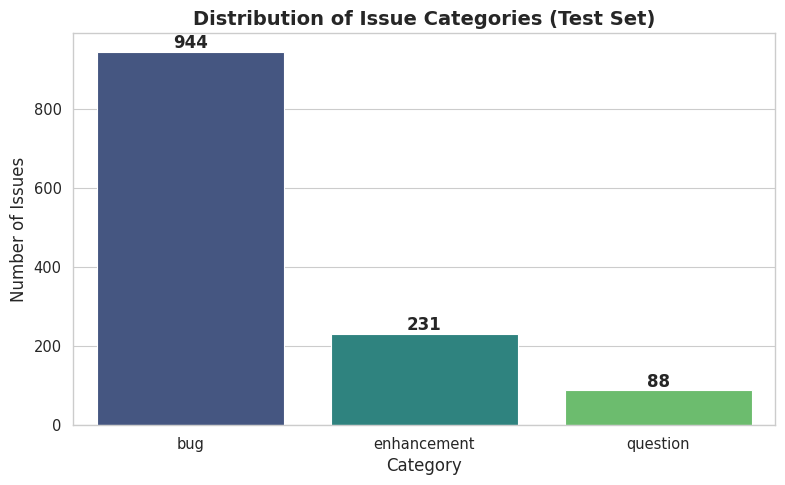

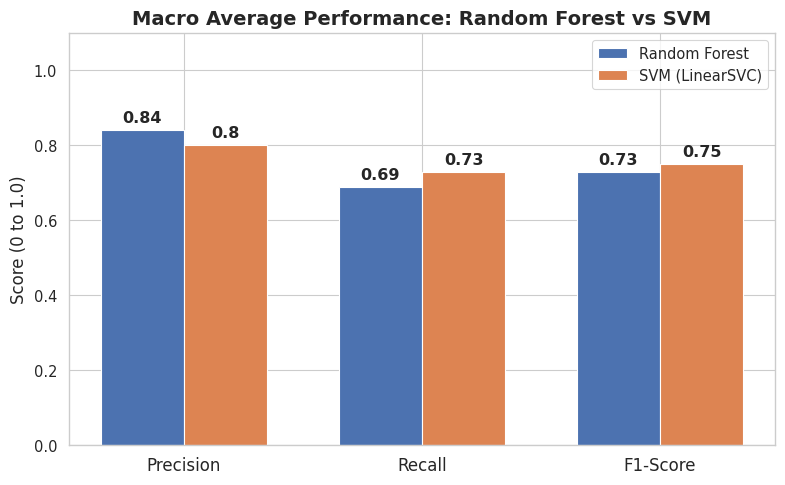

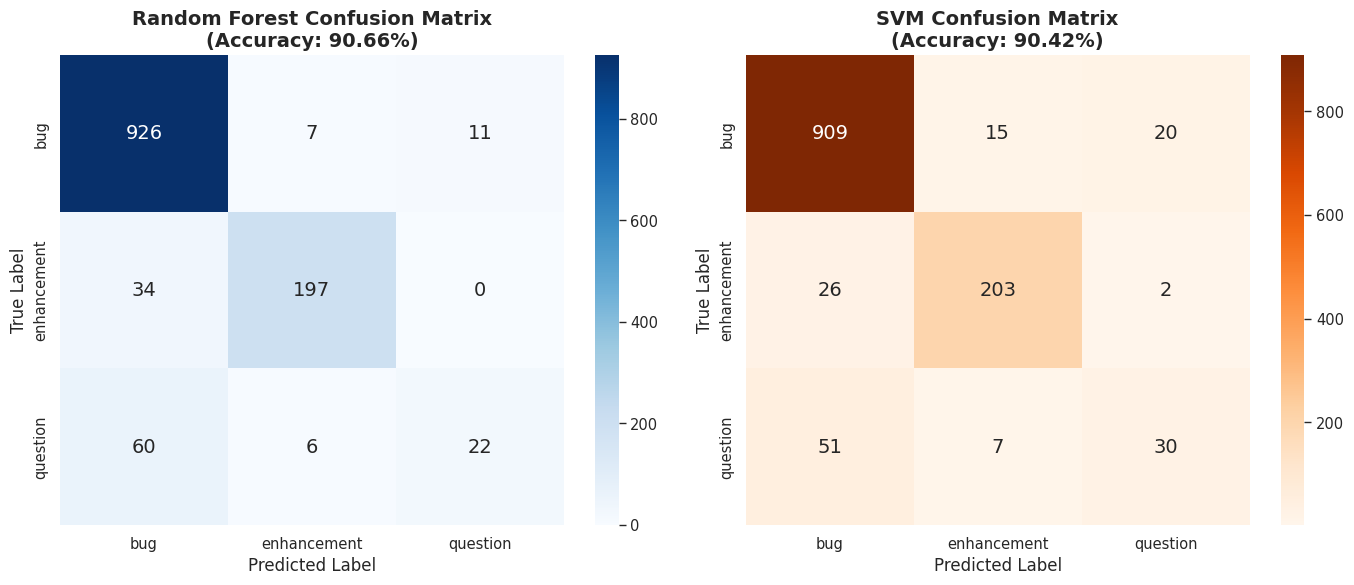


All graphs generated and saved as high-resolution PNG files!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Set the visual style for academic papers
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Ensure we have the exact classes
labels = ['bug', 'enhancement', 'question']


# Class Distribution in Test Set
plt.figure(figsize=(8, 5))
class_counts = [944, 231, 88]
sns.barplot(x=labels, y=class_counts, palette="viridis")
plt.title('Distribution of Issue Categories (Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Issues', fontsize=12)
plt.xlabel('Category', fontsize=12)
for i, count in enumerate(class_counts):
    plt.text(i, count + 10, str(count), ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('Graph1_Class_Distribution.png', dpi=300) # Saves at 300 DPI for high quality
plt.show()


# Model Performance Comparison
metrics = ['Precision', 'Recall', 'F1-Score']
rf_macro = [0.84, 0.69, 0.73]
svm_macro = [0.80, 0.73, 0.75]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, rf_macro, width, label='Random Forest', color='#4c72b0')
plt.bar(x + width/2, svm_macro, width, label='SVM (LinearSVC)', color='#dd8452')

plt.title('Macro Average Performance: Random Forest vs SVM', fontsize=14, fontweight='bold')
plt.ylabel('Score (0 to 1.0)', fontsize=12)
plt.xticks(x, metrics, fontsize=12)
plt.ylim(0, 1.1)
plt.legend(loc='upper right')

# Add numbers on top of bars
for i in range(len(rf_macro)):
    plt.text(i - width/2, rf_macro[i] + 0.02, str(rf_macro[i]), ha='center', fontweight='bold')
    plt.text(i + width/2, svm_macro[i] + 0.02, str(svm_macro[i]), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('Graph2_Performance_Comparison.png', dpi=300)
plt.show()


# Confusion Matrices (Heatmaps)
rf_cm = confusion_matrix(y_test, rf_predictions, labels=labels)
svm_cm = confusion_matrix(y_test, svm_predictions, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Random Forest Confusion Matrix
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels, annot_kws={"size": 14})
axes[0].set_title('Random Forest Confusion Matrix\n(Accuracy: 90.66%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# Plot SVM Confusion Matrix
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=labels, yticklabels=labels, annot_kws={"size": 14})
axes[1].set_title('SVM Confusion Matrix\n(Accuracy: 90.42%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.savefig('Graph3_Confusion_Matrices.png', dpi=300)
plt.show()

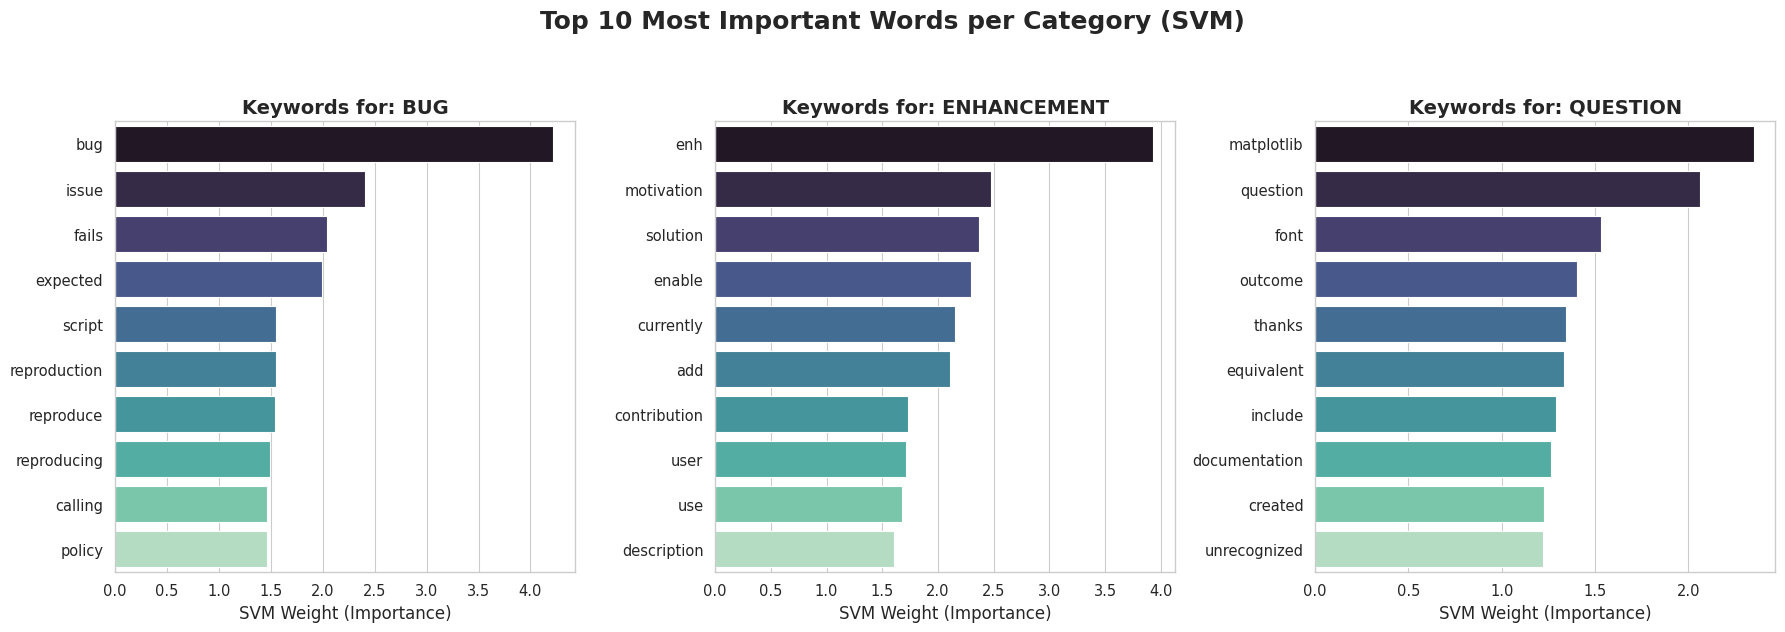


Feature Importance graph generated and saved as 'Graph4_Feature_Importance.png'!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# 1. Get the vocabulary (the actual words) from TF-IDF vectorizer
feature_names = tfidf.get_feature_names_out()

# 2. Get the mathematical weights learned by the SVM
svm_coef = svm_model.coef_

# Ensure labels are ordered correctly based on your model's classes
model_classes = svm_model.classes_

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Top 10 Most Important Words per Category (SVM)', fontsize=18, fontweight='bold', y=1.05)

# Loop through each category to plot the top 10 words
for i, label in enumerate(model_classes):
    # Sort the weights and get the top 10 highest scoring words for this category
    top10_indices = svm_coef[i].argsort()[-10:][::-1]
    top10_words = [feature_names[j] for j in top10_indices]
    top10_weights = svm_coef[i][top10_indices]

    # Create a bar chart for this category
    sns.barplot(x=top10_weights, y=top10_words, ax=axes[i], palette="mako")
    axes[i].set_title(f'Keywords for: {label.upper()}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('SVM Weight (Importance)', fontsize=12)
    axes[i].set_ylabel('') # Hide y-axis label for cleaner look

plt.tight_layout()
plt.savefig('Graph4_Feature_Importance.png', dpi=300, bbox_inches='tight')
plt.show()